In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
import os
import hubble_fit
from hubble_fit import *
from hubble_utils import *
from hubble_likelihood import *
from hubble_plotting import *
from hubble_model import *
from hubble_completeness_refactored import *

CPU Num Cores: 30


In [2]:
# IF SLOW, set speed to "test"
# speed = "test"
speed = "test"

prefix = f"mar8_{speed}"
os.environ['PREFIX'] = prefix

cosmo_model = "Flatw0waCDM"

h5_file = "results/data/nov10a_single_chisq_carma_mixscalar_nozband_highertaufastlim_removemix_fixband_lagblrband_chisq_spl_nofhost_bwb_lmc-6_N1w1000s200t14ch4.h5"
spectra_fit_csv = "results/data/nov12a_11c_single_scratch_nov10a_carma_removemix_fixmeanband_no1pluszflux2L_freeiron_mc50_best.csv"


df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = hubble_fit.load_pantheon_data()
df_agn, df_agn_all = hubble_fit.load_agn_data(h5_file,
                       fhost_cut=0.0,
                       only_load=False,
                       spectra_fit_csv=[spectra_fit_csv],
                       #zquery_csv='results/data/sep19_chisq_zquery.csv',
                       sdss_mags_csv="results/data/nov2_sdss_mags.csv", pickled=True)

Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Selected SNe: 1657 / 1701 (kept 1657; dropped 44).
Number of quasars loaded: 13090
Entire Sample file length: 13193
Populating spectra fit data from: ['results/data/nov12a_11c_single_scratch_nov10a_carma_removemix_fixmeanband_no1pluszflux2L_freeiron_mc50_best.csv']
Loading spectra fit CSV (1/1): results/data/nov12a_11c_single_scratch_nov10a_carma_removemix_fixmeanband_no1pluszflux2L_freeiron_mc50_best.csv
Length of merged DataFrame (best=True): 13090
Cut on apparent_mag_2500 : 259 objects removed
[WARNING] zquery_csv not provided, assuming zquery fields are in agn h5 file
[WARNING] zquery fields not in data, setting zWarning and sameZ to -99
['usrid', 'separation', 'probability', 'name', 'ra', 'dec', 'err_ellipse_r0', 'err_ellipse_r1', 'err_ellipse_ang', 'significance', 'likelihood_class', 'conf_flag', 'sat_src_flag', 'streak_src_flag', 'flux_aper_b', 'flux_aper_lolim_b', 'flux_aper_h

In [6]:
r = hubble_fit.run_single(df_agn, df_agn_all, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model, completeness=True, use_full_cov=True, 
                    resume=f"results/hubble_posteriors/{prefix}/posteriors_{cosmo_model}_joint_{speed}.h5",
                    only_sna=False, speed=speed, skip_plots=False)

flat_samples, model_labels, dm_interp, _, _, _, _ = r

Running sampling with 9 parameters for cosmological model: Flatw0waCDM
Smoothing counts with sigma_mag=0.2 mag (sigma_mag/dm=1.0909090909091106), sigma_z=0.5 absolute z
log_sigma mean: -0.74
sigma mean: 0.19
log_tau UV RF mean: 2.73
tau UV RF mean: 753.06
z mean: 1.560, calculated z pivot: 1.492
Checkpoint file: results/hubble_posteriors/posteriors_Flatw0waCDM_joint_production.h5
Starting Hubble Fit with 6992 AGNs and 1657 SNes...
[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/hubble_posteriors/mar8_production/posteriors_Flatw0waCDM_joint_production.h5
          M0_sn: -19.2433 (+0.0300, -0.0297)
         M0_agn: -22.4233 (+0.0501, -0.0475)
      alpha_agn: 6.3089 (+0.1614, -0.1573)
       beta_agn: -1.5565 (+0.0814, -0.0849)
          log_f: -0.2169 (+0.0280, -0.0290)
             H0: 72.6510 (+1.1092, -1.0760)
            Om0: 0.5650 (+0.0223, -0.0256)
             w0: -0.4570 (+0.4171, -0.3782)
             wa: -16.4497 (+5.2993, -6.0732)
Computing

Using linear-z bins: [0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4]
Plotting binned AGN (linear z) at: [0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9 2.1 2.3 2.5 2.7 2.9 3.1 3.3]
	mask_out: [False False False False False False False False False False False False
 False False  True]


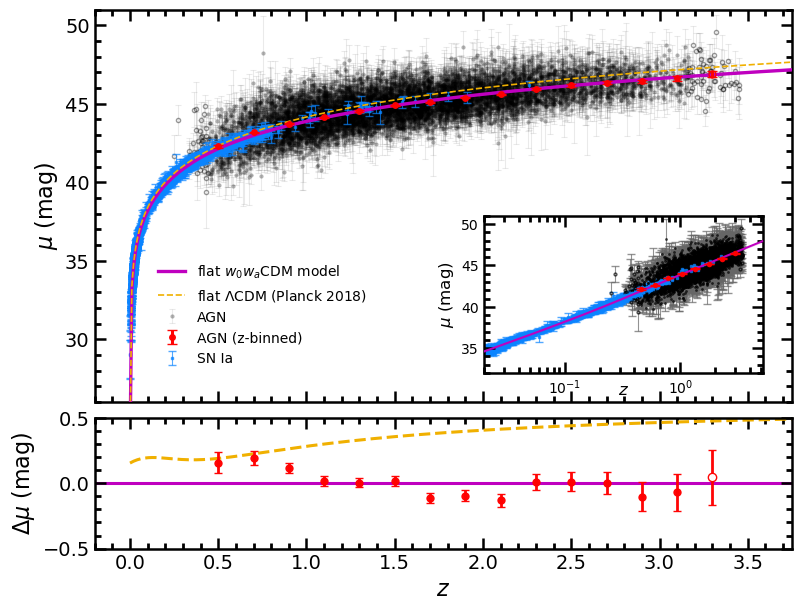

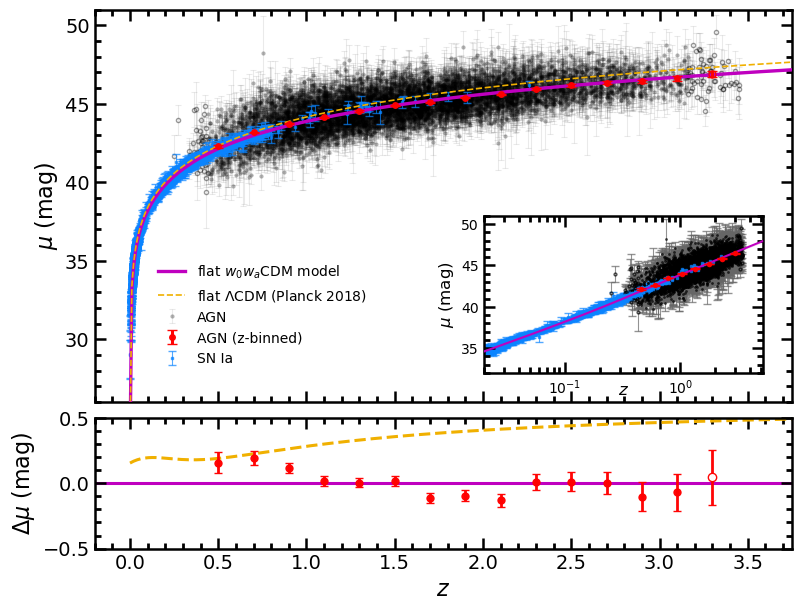

Residuals saved to plots/hubble/mar8_production/residuals.csv
Outliers (|residuals| > 5) saved to plots/hubble/mar8_production/outliers.csv


In [7]:
residuals, residuals_err, mu_pred_median, mu_pred_std, mu_pred_std_with_scatter = plot_hubble(flat_samples, df_agn, df_pantheon, cosmo_model, z_pivot_agn,
            plot_path=f"plots/hubble/{prefix}", show_binned_agn=True, show_residuals=True,
            debias=True, dm_interp=dm_interp, show=True, completeness=True, verbose=False,
            cosmo_model_samples={})